# ViT W4 architecture-stratified sensitivity and W4/W8 comparison

This compute-bounded follow-up to notebook 19 compares mathematical 4-bit per-channel PTQ and scalar codebook quantization on the **complete 10,000-image CIFAR-10 test split**. It isolates seven architecture-spanning ViT modules, evaluates full-model W4, and joins the matching full W8 results saved by notebook 19.

Only weights are quantized. Activations remain FP32 Keras activations, and no fake-quantization operators are used. The seven-module sample is predefined by architecture rather than selected from the W8 results, avoiding post-hoc selection for the isolated W4 experiment.

In [1]:
from pathlib import Path
import gc, json, platform, re, sys, time
import keras, keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists(): raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from src.models import CIFAR10_CLASS_NAMES, VIT_BASE_PATCH16_224_IMAGENET_PRESET
from src.quantization.custom_quantization import (
    codebook_vectorize_model_n_bits, custom_ptq_n_bits, dequantize_tensor, reconstruct_codebook_tensor,
)
print(f"Python: {sys.version.split()[0]}; TensorFlow: {tf.__version__}; Keras: {keras.__version__}; SciPy: {scipy.__version__}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7; TensorFlow: 2.20.0; Keras: 3.14.1; SciPy: 1.18.0


## 1. Fixed, compute-bounded protocol

In [2]:
MODEL_PATH = PROJECT_ROOT / "artifacts" / "vit_cifar10_ptq" / "vit_cifar10_fp32.keras"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "vit_4bit_stratified_sensitivity"
W8_OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "vit_full_layer_sensitivity"
CACHE_VERSION = "v1_w4_stratified_7_modules_full_cifar10"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"
W8_PREDICTION_DIR = W8_OUTPUT_DIR / "cache" / "v1_w8_per_channel_vs_k256_scalar_full_cifar10" / "predictions"

NUM_BITS, CODEBOOK_SIZE = 4, 2 ** 4
NUM_TEST_IMAGES, BATCH_SIZE = 10_000, 32
PTQ_PER_CHANNEL = True
CODEBOOK_VECTOR_DIM, CODEBOOK_DTYPE = 1, np.float32
CODEBOOK_ITERATIONS, CODEBOOK_MAX_SAMPLES = 30, 100_000
RANDOM_SEED, FORCE_RECOMPUTE = 42, False
STRATIFIED_MODULES = (
    "input_embedding", "transformer_block_1", "transformer_block_3",
    "transformer_block_6", "transformer_block_9", "transformer_block_11", "classifier",
)
METHODS = {"ptq_w4": "Custom per-channel 4-bit PTQ", "codebook_w4": "Custom scalar codebook W4 (K=16)"}
METHOD_FAMILY = {"ptq_w4": "ptq", "codebook_w4": "codebook"}

if not MODEL_PATH.exists(): raise FileNotFoundError(f"Missing ViT checkpoint: {MODEL_PATH}. Run notebook 10 first.")
if not (W8_OUTPUT_DIR / "module_sensitivity_all_methods.csv").exists(): raise FileNotFoundError("Run notebook 19 completely first.")
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR): directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print(f"W4 output: {OUTPUT_DIR}")
print(f"Seven isolated modules x two methods + two full W4 + two W8-transfer protection runs = at most 18 new inference passes.")

W4 output: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/vit_4bit_stratified_sensitivity
Seven isolated modules x two methods + two full W4 + two W8-transfer protection runs = at most 18 new inference passes.


## 2. Load all CIFAR-10 test images and the trained ViT

In [3]:
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
assert len(test_images) == len(test_labels) == NUM_TEST_IMAGES
image_converter = keras_hub.layers.ViTImageConverter(
    image_size=(224, 224), scale=[1 / 127.5] * 3, offset=[-1.0] * 3,
    interpolation="bilinear", antialias=False, crop_to_aspect_ratio=True,
)
def preprocess_images(images): return image_converter(images)

model = keras.models.load_model(MODEL_PATH, compile=False)
baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))

def module_for_tensor(name):
    if name.startswith("vit_patching_and_embedding/"): return "input_embedding"
    match = re.match(r"vit_encoder/(transformer_block_\d+)/", name)
    if match: return match.group(1)
    if name.startswith("predictions/"): return "classifier"
    raise ValueError(name)

candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    name = getattr(weight, "path", weight.name)
    selected = np.issubdtype(values.dtype, np.floating) and values.ndim >= 2 and (
        name.endswith("/kernel") or name.endswith("/embeddings") or name.endswith("class_token")
    )
    if selected:
        candidate_rows.append({"tensor_index": len(candidate_rows), "weight_index": weight_index, "tensor": name,
            "module": module_for_tensor(name), "shape": tuple(values.shape), "parameter_count": int(values.size), "fp32_bytes": int(values.nbytes)})
candidate_table = pd.DataFrame(candidate_rows)
assert len(candidate_table) == 76, f"Expected 76 meaningful tensors, found {len(candidate_table)}"
candidate_names = candidate_table.tensor.tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
module_to_tensors = {module: candidate_table[candidate_table.module == module].tensor.tolist() for module in STRATIFIED_MODULES}
assert all(module_to_tensors.values()) and set(STRATIFIED_MODULES).issubset(set(candidate_table.module))
coverage = candidate_table.groupby("module", as_index=False).agg(tensor_count=("tensor", "count"), parameter_count=("parameter_count", "sum"), fp32_bytes=("fp32_bytes", "sum"))
coverage["stratified_sample"] = coverage.module.isin(STRATIFIED_MODULES)
display(coverage); print(f"FP32 parameters: {fp32_parameter_bytes / 1024**2:.2f} MiB")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,module,tensor_count,parameter_count,fp32_bytes,stratified_sample
0,classifier,1,7680,30720,True
1,input_embedding,3,741888,2967552,True
2,transformer_block_1,6,7077888,28311552,True
3,transformer_block_10,6,7077888,28311552,False
4,transformer_block_11,6,7077888,28311552,True
5,transformer_block_12,6,7077888,28311552,False
6,transformer_block_2,6,7077888,28311552,False
7,transformer_block_3,6,7077888,28311552,True
8,transformer_block_4,6,7077888,28311552,False
9,transformer_block_5,6,7077888,28311552,False


FP32 parameters: 327.33 MiB


## 3. Resumable reconstruction and full-dataset inference helpers

In [4]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)
def predict_logits(raw_images):
    outputs = []
    for start in range(0, len(raw_images), BATCH_SIZE):
        outputs.append(evaluation_model(preprocess_images(raw_images[start:start+BATCH_SIZE]), training=False).numpy())
    return np.concatenate(outputs).astype(np.float32)
def prediction_cache_path(tag): return PREDICTION_CACHE_DIR / f"{tag}.npz"
def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached: predictions = cached["predictions"]
        if len(predictions) != NUM_TEST_IMAGES: raise ValueError(f"Stale cache: {path}")
        return predictions, True
    evaluation_model.set_weights(weights); predictions = np.argmax(predict_logits(test_images), axis=1).astype(np.int16)
    np.savez_compressed(path, predictions=predictions); return predictions, False
def weights_with_names(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names: weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights
def packed_ptq_bytes(tensor): return int((tensor.values.size * NUM_BITS + 7) // 8 + np.asarray(tensor.scale).nbytes)

def prepare_reconstructions(method):
    names = set(candidate_names); reconstructed, storage = {}, {}
    complete = not FORCE_RECOMPUTE
    for row in candidate_table.itertuples(index=False):
        path = RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{row.tensor_index:02d}.npz"
        if not path.exists(): complete = False; break
        with np.load(path) as cached: reconstructed[row.tensor], storage[row.tensor] = cached["reconstructed"], int(cached["storage_bytes"])
    if complete: print(f"Loaded 76 cached {method} tensors."); return reconstructed, storage
    if method == "ptq_w4":
        result = custom_ptq_n_bits(model, num_bits=NUM_BITS, per_channel=PTQ_PER_CHANNEL, included_tensor_names=names)["weights"]
        reconstruct, size = dequantize_tensor, packed_ptq_bytes
    elif method == "codebook_w4":
        result = codebook_vectorize_model_n_bits(model, num_bits=NUM_BITS, vector_dim=CODEBOOK_VECTOR_DIM, mode="vector",
            included_tensor_names=names, codebook_dtype=CODEBOOK_DTYPE, max_kmeans_samples=CODEBOOK_MAX_SAMPLES,
            kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED)
        reconstruct, size = reconstruct_codebook_tensor, lambda tensor: int(tensor.estimated_compressed_size_bytes)
    else: raise ValueError(method)
    for tensor in result.tensors:
        row = candidate_by_name[tensor.name]; value = reconstruct(tensor).astype(baseline_weights[row["weight_index"]].dtype); byte_count = size(tensor)
        np.savez_compressed(RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{candidate_table[candidate_table.tensor == tensor.name].tensor_index.iloc[0]:02d}.npz", reconstructed=value, storage_bytes=byte_count)
        reconstructed[tensor.name], storage[tensor.name] = value, byte_count
    if set(reconstructed) != names: raise RuntimeError(f"Incomplete reconstruction for {method}")
    return reconstructed, storage

def error_metrics(names, replacements):
    error2 = signal = absolute = count = 0.0
    for name in names:
        original = baseline_weights[candidate_by_name[name]["weight_index"]].astype(np.float64); rebuilt = replacements[name].astype(np.float64)
        delta = original - rebuilt; error2 += np.sum(delta**2); signal += np.sum(original**2); absolute += np.sum(np.abs(delta)); count += original.size
    return {"weight_mse": float(error2/count), "weight_nmse": float(error2/signal), "weight_mae": float(absolute/count),
            "weight_sqnr_db": float(10*np.log10(signal/error2)) if error2 else float("inf")}
def paired_metrics(reference, candidate):
    ref_ok, cand_ok = reference == test_labels, candidate == test_labels
    cw, wc = int(np.sum(ref_ok & ~cand_ok)), int(np.sum(~ref_ok & cand_ok)); discordant = cw + wc
    return {"prediction_disagreement_percent": float(np.mean(reference != candidate)*100), "correct_to_wrong": cw, "wrong_to_correct": wc,
            "mcnemar_p_value": float(binomtest(cw, discordant, .5).pvalue) if discordant else 1.0}
def fdr_bh(values):
    values=np.asarray(values,float); order=np.argsort(values); ranked=values[order]*len(values)/np.arange(1,len(values)+1)
    ranked=np.minimum.accumulate(ranked[::-1])[::-1]; out=np.empty_like(ranked); out[order]=np.clip(ranked,0,1); return out

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 4. Prepare all W4 weights and reuse the notebook 19 FP32 prediction cache

In [5]:
reconstructed_by_method, storage_by_method = {}, {}
for method in METHODS:
    start=time.perf_counter(); reconstructed_by_method[method], storage_by_method[method] = prepare_reconstructions(method)
    print(f"{method}: {time.perf_counter()-start:.1f}s")

w8_fp32_cache = W8_PREDICTION_DIR / "fp32_full_cifar10_test.npz"
if w8_fp32_cache.exists() and not FORCE_RECOMPUTE:
    with np.load(w8_fp32_cache) as cached: fp32_predictions = cached["predictions"]
    np.savez_compressed(prediction_cache_path("fp32_full_cifar10_test"), predictions=fp32_predictions); fp32_cache_hit=True
else: fp32_predictions, fp32_cache_hit = evaluate_weights("fp32_full_cifar10_test", baseline_weights)
fp32_accuracy=float(np.mean(fp32_predictions == test_labels))
print(f"FP32: {fp32_accuracy*100:.2f}% ({np.sum(fp32_predictions == test_labels)}/{NUM_TEST_IMAGES}); cache={fp32_cache_hit}")

ptq_w4: 11.2s
codebook_w4: 39.4s
FP32: 95.73% (9573/10000); cache=True


## 5. Isolated W4 sensitivity of the seven predefined modules

In [6]:
rows=[]; sensitivity_path=OUTPUT_DIR / "w4_stratified_module_sensitivity.csv"
for method in METHODS:
    for module_index, module in enumerate(STRATIFIED_MODULES):
        names=module_to_tensors[module]; tag=f"module_{method}_{module}_full_cifar10"; start=time.perf_counter()
        predictions, cache_hit=evaluate_weights(tag, weights_with_names(reconstructed_by_method[method], names))
        accuracy=float(np.mean(predictions == test_labels)); row={"method":method,"method_family":METHOD_FAMILY[method],"method_label":METHODS[method],
            "bit_width":NUM_BITS,"module":module,"module_index":module_index,"tensor_count":len(names),
            "parameter_count":int(sum(candidate_by_name[n]["parameter_count"] for n in names)),"fp32_accuracy_percent":fp32_accuracy*100,
            "quantized_accuracy_percent":accuracy*100,"accuracy_degradation_pp":(fp32_accuracy-accuracy)*100,"evaluation_seconds":time.perf_counter()-start,
            "prediction_cache_hit":cache_hit,"prediction_cache_tag":tag}
        row.update(error_metrics(names,reconstructed_by_method[method])); row.update(paired_metrics(fp32_predictions,predictions)); rows.append(row)
        pd.DataFrame(rows).to_csv(sensitivity_path,index=False); print(f"{method} {module}: {accuracy*100:.2f}% | cache={cache_hit}")
w4_sensitivity=pd.DataFrame(rows); w4_sensitivity["mcnemar_fdr_p_value"]=np.nan
for method in METHODS:
    mask=w4_sensitivity.method==method; w4_sensitivity.loc[mask,"mcnemar_fdr_p_value"]=fdr_bh(w4_sensitivity.loc[mask,"mcnemar_p_value"])
w4_sensitivity["sensitivity_rank_w4"]=w4_sensitivity.groupby("method")["accuracy_degradation_pp"].rank(method="first",ascending=False).astype(int)
w4_sensitivity.to_csv(sensitivity_path,index=False)
display(w4_sensitivity.sort_values(["method","sensitivity_rank_w4"])[["method_label","sensitivity_rank_w4","module","quantized_accuracy_percent","accuracy_degradation_pp","prediction_disagreement_percent","weight_nmse","mcnemar_fdr_p_value"]])

ptq_w4 input_embedding: 95.91% | cache=False
ptq_w4 transformer_block_1: 95.88% | cache=False
ptq_w4 transformer_block_3: 95.70% | cache=False
ptq_w4 transformer_block_6: 95.69% | cache=False
ptq_w4 transformer_block_9: 95.74% | cache=False
ptq_w4 transformer_block_11: 95.71% | cache=False
ptq_w4 classifier: 95.72% | cache=False
codebook_w4 input_embedding: 95.91% | cache=False
codebook_w4 transformer_block_1: 95.53% | cache=False
codebook_w4 transformer_block_3: 95.78% | cache=False
codebook_w4 transformer_block_6: 95.68% | cache=False
codebook_w4 transformer_block_9: 95.71% | cache=False
codebook_w4 transformer_block_11: 95.73% | cache=False
codebook_w4 classifier: 95.80% | cache=False


,method_label,sensitivity_rank_w4,module,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,weight_nmse,mcnemar_fdr_p_value
8,Custom scalar codebook W4 (K=16),1,transformer_block_1,95.53,0.20,0.85,0.020564,0.124540
10,Custom scalar codebook W4 (K=16),2,transformer_block_6,95.68,0.05,0.62,0.017501,0.816385
11,Custom scalar codebook W4 (K=16),3,transformer_block_9,95.71,0.02,0.54,0.011232,1.000000
12,Custom scalar codebook W4 (K=16),4,transformer_block_11,95.73,0.00,0.49,0.011200,1.000000
9,Custom scalar codebook W4 (K=16),5,transformer_block_3,95.78,-0.05,0.62,0.012967,0.816385
13,Custom scalar codebook W4 (K=16),6,classifier,95.80,-0.07,0.31,0.008790,0.441577
7,Custom scalar codebook W4 (K=16),7,input_embedding,95.91,-0.18,0.79,0.015903,0.124540
3,Custom per-channel 4-bit PTQ,1,transformer_block_6,95.69,0.04,0.70,0.031960,1.000000
2,Custom per-channel 4-bit PTQ,2,transformer_block_3,95.70,0.03,0.74,0.038354,1.000000
5,Custom per-channel 4-bit PTQ,3,transformer_block_11,95.71,0.02,0.67,0.031542,1.000000


## 6. Matched W4/W8 module comparison and rank stability

In [7]:
w8=pd.read_csv(W8_OUTPUT_DIR / "module_sensitivity_all_methods.csv")
w8["method_family"]=w8.method.map({"ptq_w8":"ptq","codebook_w8":"codebook"}); w8=w8[w8.analysis_unit.isin(STRATIFIED_MODULES)].copy()
w8_ranked=pd.read_csv(W8_OUTPUT_DIR / "final_ranked_module_sensitivity.csv")
w8_ranked["method_family"]=w8_ranked.method.map({"ptq_w8":"ptq","codebook_w8":"codebook"})
w8=w8.merge(w8_ranked[["method_family","analysis_unit","sensitivity_rank"]],on=["method_family","analysis_unit"],how="left").rename(columns={"analysis_unit":"module","sensitivity_rank":"global_sensitivity_rank_w8"})
left=w4_sensitivity.rename(columns={c:f"{c}_w4" for c in ["quantized_accuracy_percent","accuracy_degradation_pp","prediction_disagreement_percent","weight_nmse"]})
right=w8.rename(columns={c:f"{c}_w8" for c in ["quantized_accuracy_percent","accuracy_degradation_pp","prediction_disagreement_percent","weight_nmse"]})
comparison=left.merge(right[["method_family","module","quantized_accuracy_percent_w8","accuracy_degradation_pp_w8","prediction_disagreement_percent_w8","weight_nmse_w8","global_sensitivity_rank_w8"]],on=["method_family","module"],validate="one_to_one")
comparison["sample_rank_w8"]=comparison.groupby("method_family")["accuracy_degradation_pp_w8"].rank(method="first",ascending=False).astype(int)
comparison["additional_w4_degradation_pp"]=comparison.accuracy_degradation_pp_w4-comparison.accuracy_degradation_pp_w8
comparison.to_csv(OUTPUT_DIR / "stratified_module_w4_vs_w8.csv",index=False)
rank_rows=[]
for family,group in comparison.groupby("method_family"):
    corr=spearmanr(group.sensitivity_rank_w4,group.sample_rank_w8)
    rank_rows.append({"method_family":family,"sampled_modules":len(group),"w4_w8_rank_spearman_rho":float(corr.statistic),"p_value":float(corr.pvalue),
        "mean_degradation_w4_pp":group.accuracy_degradation_pp_w4.mean(),"mean_degradation_w8_pp":group.accuracy_degradation_pp_w8.mean()})
rank_summary=pd.DataFrame(rank_rows); rank_summary.to_csv(OUTPUT_DIR / "w4_w8_rank_stability.csv",index=False)
display(comparison); display(rank_summary)

,method,method_family,method_label,bit_width,module,module_index,tensor_count,parameter_count,fp32_accuracy_percent,quantized_accuracy_percent_w4,...,mcnemar_p_value,mcnemar_fdr_p_value,sensitivity_rank_w4,quantized_accuracy_percent_w8,accuracy_degradation_pp_w8,prediction_disagreement_percent_w8,weight_nmse_w8,global_sensitivity_rank_w8,sample_rank_w8,additional_w4_degradation_pp
0,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,input_embedding,0,3,741888,95.73,95.91,...,0.078976,0.552829,7,95.75,-0.02,0.03,0.000046,6,2,-0.16
1,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,transformer_block_1,1,6,7077888,95.73,95.88,...,0.195349,0.683722,6,95.74,-0.01,0.07,0.000304,2,1,-0.14
2,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,transformer_block_3,2,6,7077888,95.73,95.70,...,0.798153,1.000000,2,95.75,-0.02,0.08,0.000119,4,3,0.05
3,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,transformer_block_6,3,6,7077888,95.73,95.69,...,0.698883,1.000000,1,95.75,-0.02,0.05,0.000103,5,4,0.06
4,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,transformer_block_9,4,6,7077888,95.73,95.74,...,1.000000,1.000000,5,95.79,-0.06,0.08,0.000090,14,7,0.05
5,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,transformer_block_11,5,6,7077888,95.73,95.71,...,0.895683,1.000000,3,95.78,-0.05,0.06,0.000096,13,6,0.07
6,ptq_w4,ptq,Custom per-channel 4-bit PTQ,4,classifier,6,1,7680,95.73,95.72,...,1.000000,1.000000,4,95.75,-0.02,0.03,0.000046,7,5,0.03
7,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,input_embedding,0,3,741888,95.73,95.91,...,0.035583,0.124540,7,95.73,0.00,0.05,0.000069,4,3,-0.18
8,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,transformer_block_1,1,6,7077888,95.73,95.53,...,0.028627,0.124540,1,95.79,-0.06,0.11,0.000285,14,7,0.26
9,codebook_w4,codebook,Custom scalar codebook W4 (K=16),4,transformer_block_3,2,6,7077888,95.73,95.78,...,0.575849,0.816385,5,95.70,0.03,0.21,0.000223,2,2,-0.08


,method_family,sampled_modules,w4_w8_rank_spearman_rho,p_value,mean_degradation_w4_pp,mean_degradation_w8_pp
0,codebook,7,-0.357143,0.431611,-0.004286,-0.012857
1,ptq,7,-0.321429,0.482072,-0.034286,-0.028571


## 7. Full-model W4 accuracy, compression, and W8-rank transfer protection

In [8]:
def representation_bytes(method,names):
    total=fp32_parameter_bytes
    for name in names: total += storage_by_method[method][name]-candidate_by_name[name]["fp32_bytes"]
    return int(total)
def evaluate_configuration(method,configuration,protected_modules=()):
    protected=set(protected_modules); names=[n for n in candidate_names if candidate_by_name[n]["module"] not in protected]
    predictions,cache=evaluate_weights(f"config_{method}_{configuration}_full_cifar10",weights_with_names(reconstructed_by_method[method],names))
    accuracy=float(np.mean(predictions==test_labels)); byte_count=representation_bytes(method,names)
    return {"method":method,"method_family":METHOD_FAMILY[method],"bit_width":NUM_BITS,"configuration":configuration,
        "protected_modules":" | ".join(sorted(protected)),"quantized_tensors":len(names),"accuracy_percent":accuracy*100,
        "accuracy_degradation_pp":(fp32_accuracy-accuracy)*100,"prediction_disagreement_percent":np.mean(predictions!=fp32_predictions)*100,
        "parameter_mib":byte_count/1024**2,"compression_ratio_vs_fp32":fp32_parameter_bytes/byte_count,
        "memory_reduction_percent":(1-byte_count/fp32_parameter_bytes)*100,"prediction_cache_hit":cache}

configuration_rows=[]
for method in METHODS:
    configuration_rows.append(evaluate_configuration(method,"full_w4"))
    family=METHOD_FAMILY[method]; w8_order=w8_ranked[w8_ranked.method_family==family].sort_values("sensitivity_rank").analysis_unit.tolist()
    configuration_rows.append(evaluate_configuration(method,"w8_top2_protected",w8_order[:2]))
w4_configurations=pd.DataFrame(configuration_rows); w4_configurations.to_csv(OUTPUT_DIR / "w4_full_and_transfer_configurations.csv",index=False)

w8_configs=pd.read_csv(W8_OUTPUT_DIR / "module_selective_quantization.csv")
w8_configs["method_family"]=w8_configs.method.map({"ptq_w8":"ptq","codebook_w8":"codebook"})
w8_full=w8_configs[w8_configs.configuration=="full_w8"][["method_family","accuracy_percent","accuracy_degradation_pp","prediction_disagreement_percent","parameter_mib","compression_ratio_vs_fp32","memory_reduction_percent"]].copy(); w8_full["bit_width"]=8
w4_full=w4_configurations[w4_configurations.configuration=="full_w4"][["method_family","accuracy_percent","accuracy_degradation_pp","prediction_disagreement_percent","parameter_mib","compression_ratio_vs_fp32","memory_reduction_percent","bit_width"]]
full_model_comparison=pd.concat([w4_full,w8_full],ignore_index=True).sort_values(["method_family","bit_width"])
full_model_comparison.to_csv(OUTPUT_DIR / "full_model_w4_vs_w8.csv",index=False)
display(w4_configurations); display(full_model_comparison)

,method,method_family,bit_width,configuration,protected_modules,quantized_tensors,accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,prediction_cache_hit
0,ptq_w4,ptq,4,full_w4,,76,95.23,0.50,3.41,41.551834,7.877516,87.305643,False
1,ptq_w4,ptq,4,w8_top2_protected,transformer_block_1 | transformer_block_4,64,95.16,0.57,2.91,88.765213,3.687540,72.881647,False
2,codebook_w4,codebook,4,full_w4,,76,95.20,0.53,2.78,41.327919,7.920196,87.374050,False
3,codebook_w4,codebook,4,w8_top2_protected,transformer_block_3 | transformer_block_6,64,95.45,0.28,2.33,88.577187,3.695367,72.939090,False


,method_family,accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,parameter_mib,compression_ratio_vs_fp32,memory_reduction_percent,bit_width
1,codebook,95.20,0.53,2.78,41.327919,7.920196,87.374050,4
3,codebook,95.73,0.00,0.63,82.254921,3.979400,74.870584,8
0,ptq,95.23,0.50,3.41,41.551834,7.877516,87.305643,4
2,ptq,95.79,-0.06,0.16,82.409256,3.971947,74.823433,8


## 8. Full-W4 per-class effects

In [9]:
class_rows=[]
for method in METHODS:
    predictions,_=evaluate_weights(f"config_{method}_full_w4_full_cifar10",weights_with_names(reconstructed_by_method[method],candidate_names))
    for class_index,class_name in enumerate(CIFAR10_CLASS_NAMES):
        mask=test_labels==class_index; fp=np.mean(fp32_predictions[mask]==test_labels[mask]); q=np.mean(predictions[mask]==test_labels[mask])
        class_rows.append({"method":method,"class_name":class_name,"fp32_accuracy_percent":fp*100,"w4_accuracy_percent":q*100,"accuracy_degradation_pp":(fp-q)*100})
per_class=pd.DataFrame(class_rows); per_class.to_csv(OUTPUT_DIR / "full_w4_per_class.csv",index=False); display(per_class)

,method,class_name,fp32_accuracy_percent,w4_accuracy_percent,accuracy_degradation_pp
0,ptq_w4,airplane,96.5,96.0,0.5
1,ptq_w4,automobile,98.2,97.4,0.8
2,ptq_w4,bird,95.3,95.6,-0.3
3,ptq_w4,cat,93.1,94.4,-1.3
4,ptq_w4,deer,96.6,95.4,1.2
5,ptq_w4,dog,93.0,90.5,2.5
6,ptq_w4,frog,95.2,94.5,0.7
7,ptq_w4,horse,98.4,97.1,1.3
8,ptq_w4,ship,96.3,97.2,-0.9
9,ptq_w4,truck,94.7,94.2,0.5


## 9. Report figures and reproducibility record

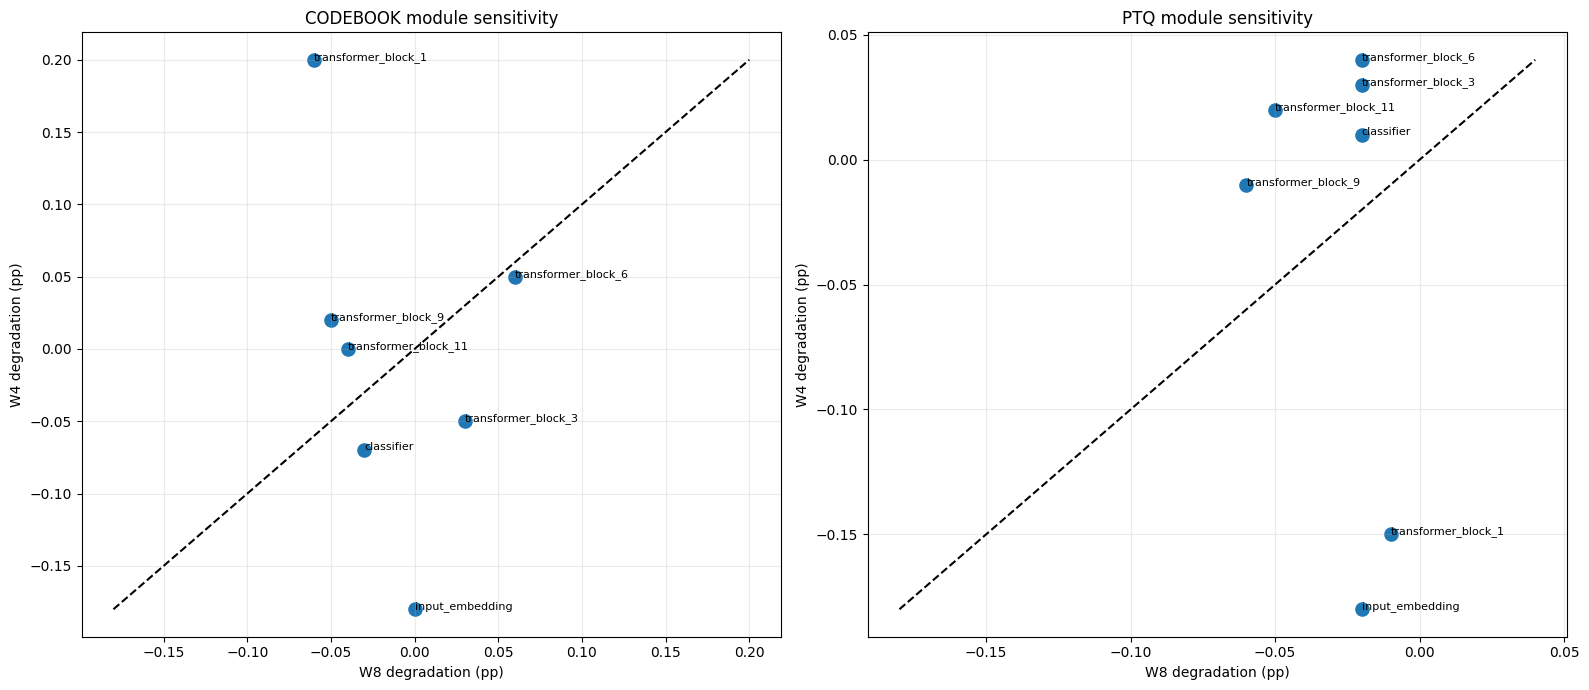

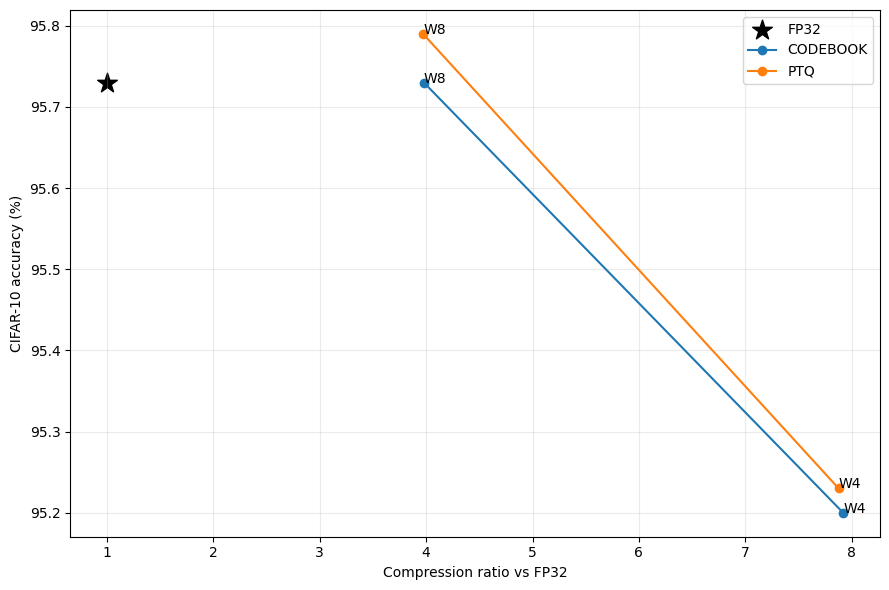

All results saved under /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/vit_4bit_stratified_sensitivity


In [10]:
fig,axes=plt.subplots(1,2,figsize=(16,7))
for axis,(family,group) in zip(axes,comparison.groupby("method_family")):
    axis.scatter(group.accuracy_degradation_pp_w8,group.accuracy_degradation_pp_w4,s=90)
    for row in group.itertuples(): axis.annotate(row.module,(row.accuracy_degradation_pp_w8,row.accuracy_degradation_pp_w4),fontsize=8)
    lo=min(group.accuracy_degradation_pp_w8.min(),group.accuracy_degradation_pp_w4.min()); hi=max(group.accuracy_degradation_pp_w8.max(),group.accuracy_degradation_pp_w4.max())
    axis.plot([lo,hi],[lo,hi],"--",color="black"); axis.set_title(f"{family.upper()} module sensitivity"); axis.set_xlabel("W8 degradation (pp)"); axis.set_ylabel("W4 degradation (pp)"); axis.grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure1_stratified_w4_vs_w8.png",dpi=180,bbox_inches="tight"); plt.show()

fig,axis=plt.subplots(figsize=(9,6)); axis.scatter([1],[fp32_accuracy*100],marker="*",s=220,color="black",label="FP32")
for family,group in full_model_comparison.groupby("method_family"):
    group=group.sort_values("bit_width"); axis.plot(group.compression_ratio_vs_fp32,group.accuracy_percent,"o-",label=family.upper())
    for row in group.itertuples(): axis.annotate(f"W{row.bit_width}",(row.compression_ratio_vs_fp32,row.accuracy_percent))
axis.set_xlabel("Compression ratio vs FP32"); axis.set_ylabel("CIFAR-10 accuracy (%)"); axis.grid(alpha=.25); axis.legend()
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "figure2_full_model_accuracy_compression.png",dpi=180,bbox_inches="tight"); plt.show()

coverage.to_csv(OUTPUT_DIR / "module_coverage.csv",index=False)
metadata={"model_checkpoint":str(MODEL_PATH),"dataset":"CIFAR-10 complete official test split","test_images":NUM_TEST_IMAGES,
    "preset":VIT_BASE_PATCH16_224_IMAGENET_PRESET,"bits":NUM_BITS,"stratified_modules":STRATIFIED_MODULES,"eligible_tensors":len(candidate_table),
    "methods":METHODS,"activations_quantized":False,"fake_quantization_used":False,
    "storage_note":"Theoretical packed 4-bit assignments plus scales/codebooks; reconstructed FP32 is used only for Keras accuracy evaluation.",
    "selection_note":"W4 isolated modules were predefined architecturally; W8-top2 protection is explicitly labelled exploratory transfer analysis.",
    "tensorflow":tf.__version__,"keras":keras.__version__,"python":sys.version,"hardware":platform.platform(),"cache_version":CACHE_VERSION}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata,indent=2,default=str))
print(f"All results saved under {OUTPUT_DIR}")

## Interpretation rules

- Compare every isolated W4 module against the same FP32 baseline; all other weights stay FP32 in that isolated run.
- Use `accuracy_degradation_pp`, prediction disagreement, McNemar/FDR, and weight NMSE together. Small differences on 10,000 images can still be sampling noise.
- The W4/W8 Spearman result measures whether sensitivity ordering transfers across bit widths within the seven predefined modules.
- Full-model rows support the accuracy–memory–compression conclusion. W8-top2 protection is exploratory because the protected modules were selected using notebook 19.
- Compression is theoretical representation size. Execution uses reconstructed weights with FP32 activations, not an indexed-codebook or packed-int4 hardware runtime.